# System 1 — Content-Based Job Recommender (TF-IDF + Structured Features)

This notebook implements a **Content-Based Filtering** recommender system for job postings using a **hybrid similarity score** that combines:

| Signal | Feature | Weight |
|---|---|---|
| Text content | TF-IDF on title + skills + description | 60% |
| Experience level | Ordinal proximity (Entry → Executive) | 15% |
| Location | State-level match | 15% |
| Salary | Normalised absolute gap | 10% |

### Dataset
LinkedIn Job Postings — `postings.csv` (~128350 rows, 31 columns)

### Pipeline
1. Exploratory Data Analysis (EDA)
2. Text preprocessing & feature engineering
3. TF-IDF vectorisation
4. Structured feature encoding (experience, location, salary)
5. Hybrid similarity recommendation engine
6. Demo
7. Evaluation

## 1. Setup

In [14]:
# Install any missing dependencies
!pip install scikit-learn pandas numpy matplotlib seaborn wordcloud --quiet

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

from wordcloud import WordCloud
from IPython.display import display

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Data

Upload `postings.csv` to your Google Drive, then mount it below.

> **Drive path assumed:** `MyDrive/postings.csv`  
> Change `FILE_PATH` if your file is in a subfolder.

In [16]:
FILE_PATH = '/content/postings.csv'

# Full dataset is 3.38M rows — we sample 50,000 for speed
# To use the full dataset, remove the nrows parameter
SAMPLE_SIZE = 50_000

print(f'Loading {SAMPLE_SIZE:,} rows from dataset...')
df_full = pd.read_csv(FILE_PATH, nrows=SAMPLE_SIZE)
print(f'Loaded: {df_full.shape[0]:,} rows x {df_full.shape[1]} columns')

Loading 50,000 rows from dataset...
Loaded: 50,000 rows x 31 columns


## 3. Exploratory Data Analysis (EDA)

In [17]:
print('=== Dataset Overview ===')
print(f'Shape: {df_full.shape}')
print()
print('=== Column Types ===')
print(df_full.dtypes)
print()
print('=== First 3 rows ===')
display(df_full[['job_id','title','company_name','location','formatted_experience_level',
                 'formatted_work_type','normalized_salary']].head(3))

=== Dataset Overview ===
Shape: (50000, 31)

=== Column Types ===
job_id                          int64
company_name                   object
title                          object
description                    object
max_salary                    float64
pay_period                     object
location                       object
company_id                    float64
views                         float64
med_salary                    float64
min_salary                    float64
formatted_work_type            object
applies                       float64
original_listed_time          float64
remote_allowed                float64
job_posting_url                object
application_url                object
application_type               object
expiry                        float64
closed_time                   float64
formatted_experience_level     object
skills_desc                    object
listed_time                   float64
posting_domain                 object
sponsored             

,job_id,title,company_name,location,formatted_experience_level,formatted_work_type,normalized_salary
0,921716,Marketing Coordinator,Corcoran Sawyer Smith,"Princeton, NJ",NaN,Full-time,38480.0
1,1829192,Mental Health Therapist/Counselor,NaN,"Fort Collins, CO",NaN,Full-time,83200.0
2,10998357,Assitant Restaurant Manager,The National Exemplar,"Cincinnati, OH",NaN,Full-time,55000.0


=== Missing Values ===


,Column,Missing Count,Missing %
0,title,0,0.0
1,description,2,0.0
2,skills_desc,49059,98.1
3,location,0,0.0
4,formatted_experience_level,14151,28.3
5,formatted_work_type,0,0.0
6,normalized_salary,35425,70.9
7,views,502,1.0
8,applies,38572,77.1


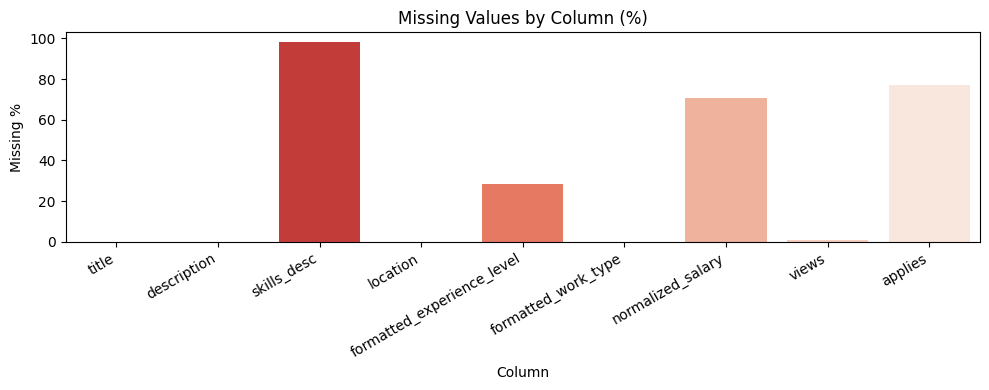

In [18]:
# --- Missing value analysis ---
key_cols = ['title','description','skills_desc','location',
            'formatted_experience_level','formatted_work_type',
            'normalized_salary','views','applies']

missing = df_full[key_cols].isnull().sum().reset_index()
missing.columns = ['Column', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df_full) * 100).round(1)

print('=== Missing Values ===')
display(missing)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=missing, x='Column', y='Missing %', palette='Reds_r', ax=ax)
ax.set_title('Missing Values by Column (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

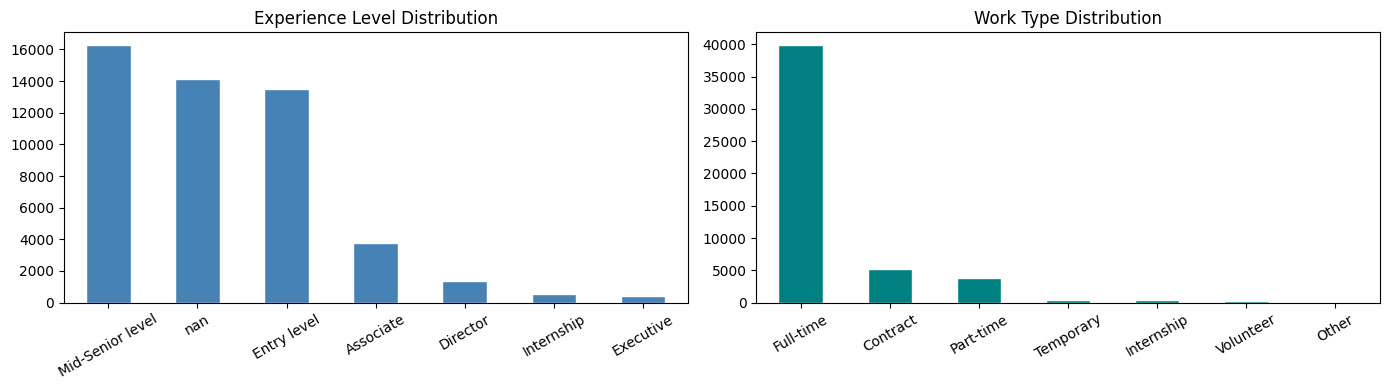

In [19]:
# --- Experience level distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

exp_counts = df_full['formatted_experience_level'].value_counts(dropna=False)
exp_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Experience Level Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

work_counts = df_full['formatted_work_type'].value_counts(dropna=False)
work_counts.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Work Type Distribution')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

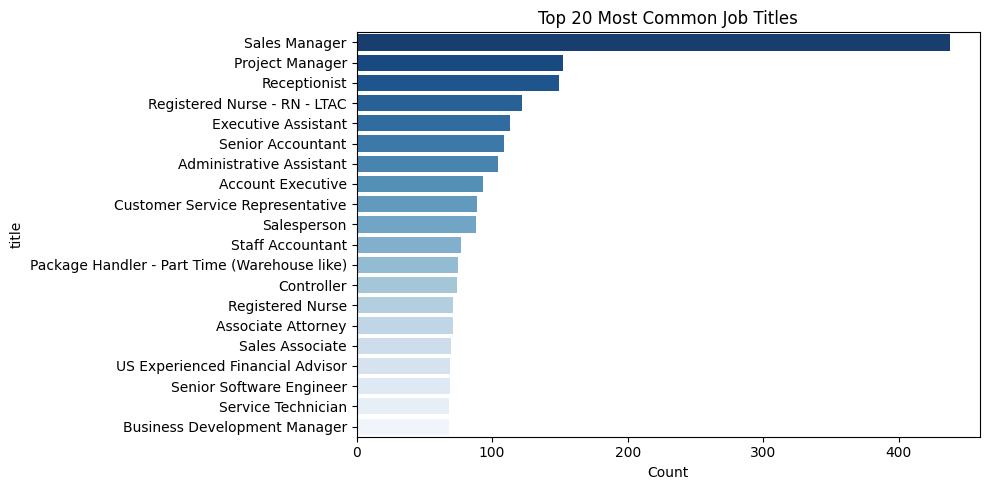

In [20]:
# --- Top job titles ---
top_titles = df_full['title'].value_counts().head(20)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_titles.values, y=top_titles.index, palette='Blues_r')
plt.title('Top 20 Most Common Job Titles')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

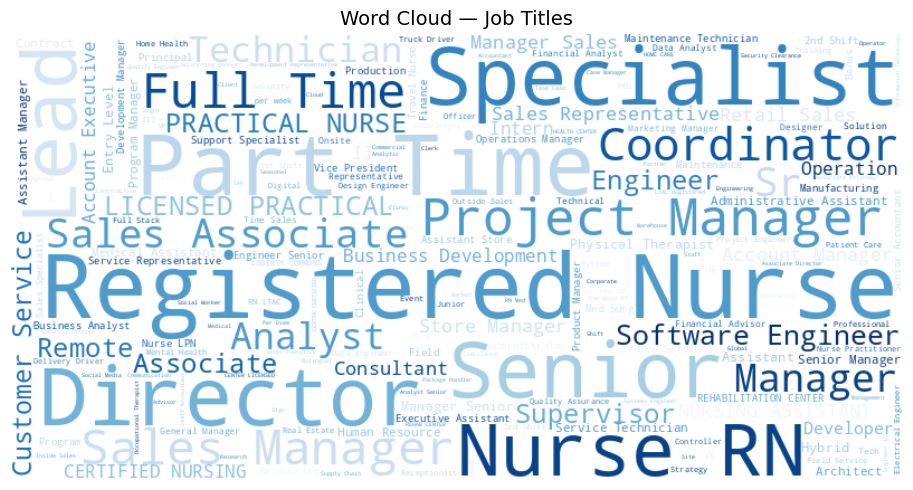

In [21]:
# --- Word cloud of job titles ---
all_titles = ' '.join(df_full['title'].dropna().values)
wc = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(all_titles)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Job Titles', fontsize=14)
plt.tight_layout()
plt.show()

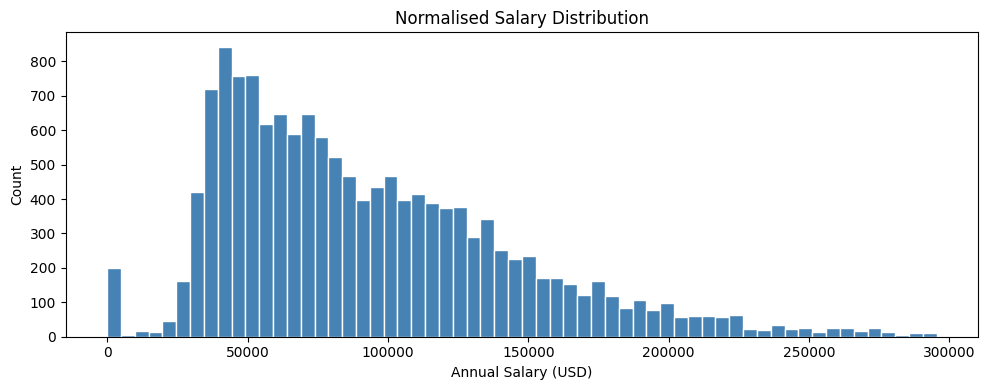

Salary stats:
count     14426.0
mean      92172.0
std       51626.0
min           0.0
25%       52000.0
50%       80000.0
75%      122500.0
max      295456.0
Name: normalized_salary, dtype: float64


In [22]:
# --- Salary distribution ---
salary_data = df_full['normalized_salary'].dropna()
salary_data = salary_data[salary_data < salary_data.quantile(0.99)]  # remove extreme outliers

plt.figure(figsize=(10, 4))
plt.hist(salary_data, bins=60, color='steelblue', edgecolor='white')
plt.title('Normalised Salary Distribution')
plt.xlabel('Annual Salary (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f'Salary stats:\n{salary_data.describe().round(0)}')

## 4. Preprocessing & Feature Engineering

### 4a. Text Features
We combine three text columns into a single `content` field:
```
content = title (×3) + description (×1)
```
Title and skills are repeated to give them higher weight before TF-IDF scoring.

### 4b. Structured Features (new)
We also encode three structured columns for use in hybrid scoring:

| Feature | Encoding |
|---|---|
| `formatted_experience_level` | Ordinal integer (Internship=0 → Executive=5), normalised 0–1 |
| `location` | Extract state code (e.g. `"Princeton, NJ"` → `"NJ"`) |
| `normalized_salary` | Min-max scaled 0–1; missing values filled with median |

In [23]:
def clean_text(text: str) -> str:
    """Lowercase, strip HTML tags, remove punctuation, collapse whitespace."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)          # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
    return text

# Work on a clean copy
df = df_full.copy()

# Fill nulls before combining
df['title']       = df['title'].fillna('')
df['description'] = df['description'].fillna('')

# Feature engineering — weighted combination:
# Title repeated 3x (highest signal), description 1x
df['content'] = (
    df['title'].apply(clean_text) + ' ' +
    df['title'].apply(clean_text) + ' ' +
    df['title'].apply(clean_text) + ' ' +
    df['description'].apply(clean_text)
)

# Drop rows with empty content
df = df[df['content'].str.strip() != ''].reset_index(drop=True)

print(f'Rows after cleaning: {len(df):,}')
print()
print('Sample content field (first job):')
print(df['content'].iloc[0][:500], '...')

Rows after cleaning: 50,000

Sample content field (first job):
marketing coordinator marketing coordinator marketing coordinator job descriptiona leading real estate firm in new jersey is seeking an administrative marketing coordinator with some experience in graphic design you will be working closely with our fun kind ambitious members of the sales team and our dynamic executive team on a daily basis this is an opportunity to be part of a fast growing highly respected real estate brokerage with a reputation for exceptional marketing and extraordinary cultu ...


In [24]:
# ── 4b. Structured Feature Encoding ──────────────────────────────────────────

# --- Experience level: ordinal encoding ---
EXP_ORDER = {
    'Internship':      0,
    'Entry level':     1,
    'Associate':       2,
    'Mid-Senior level':3,
    'Director':        4,
    'Executive':       5,
}
MAX_EXP = max(EXP_ORDER.values())   # 5

df['exp_encoded'] = df['formatted_experience_level'].map(EXP_ORDER)
# Jobs with missing experience get the median level
exp_median = df['exp_encoded'].median()
df['exp_encoded'] = df['exp_encoded'].fillna(exp_median)
df['exp_norm'] = df['exp_encoded'] / MAX_EXP   # scale to [0, 1]

# --- Location: extract state code ---
def extract_state(location: str) -> str:
    """Extract 2-letter state code from 'City, ST' format. Returns '' if not found."""
    if not isinstance(location, str):
        return ''
    parts = location.strip().split(',')
    if len(parts) >= 2:
        state = parts[-1].strip()
        if len(state) == 2:
            return state.upper()
    return ''

df['state'] = df['location'].apply(extract_state)

# --- Salary: fill missing with median, then min-max scale ---
salary_median = df['normalized_salary'].median()
df['salary_filled'] = df['normalized_salary'].fillna(salary_median)

scaler = MinMaxScaler()
df['salary_norm'] = scaler.fit_transform(df[['salary_filled']])

# --- Summary ---
print('Structured feature encoding complete.')
print(f"  Experience levels encoded  : {df['exp_norm'].notna().sum():,} rows")
print(f"  States extracted           : {(df['state'] != '').sum():,} rows with valid state")
print(f"  Salary normalised          : {df['salary_norm'].notna().sum():,} rows")
print()
print('Experience level distribution:')
print(df['formatted_experience_level'].value_counts(dropna=False).to_string())
print()
print('Top 10 states:')
print(df[df['state'] != '']['state'].value_counts().head(10).to_string())

Structured feature encoding complete.
  Experience levels encoded  : 50,000 rows
  States extracted           : 42,275 rows with valid state
  Salary normalised          : 50,000 rows

Experience level distribution:
formatted_experience_level
Mid-Senior level    16270
NaN                 14151
Entry level         13491
Associate            3786
Director             1375
Internship            512
Executive             415

Top 10 states:
state
CA    4783
TX    4046
NC    2471
NY    2304
FL    2198
IL    1844
PA    1641
VA    1454
OH    1350
MA    1300


## 5. TF-IDF Vectorisation

We convert the `content` text field into a numerical matrix where:
- Each **row** = one job posting
- Each **column** = a unique word (token)
- Each **value** = TF-IDF score of that word in that job

Key parameters:
- `max_features=15000` — keep only the 15K most informative words
- `ngram_range=(1,2)` — include single words AND two-word phrases (e.g. "machine learning")
- `min_df=2` — ignore words that appear in fewer than 2 jobs
- `max_df=0.85` — ignore words that appear in more than 85% of jobs (too common to be useful)
- `sublinear_tf=True` — apply log normalisation to term frequency

In [25]:
print('Fitting TF-IDF vectoriser...')

tfidf = TfidfVectorizer(
    max_features=15_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(df['content'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'  → {tfidf_matrix.shape[0]:,} job postings')
print(f'  → {tfidf_matrix.shape[1]:,} unique tokens')
print(f'Matrix sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.2%}')

Fitting TF-IDF vectoriser...
TF-IDF matrix shape: (50000, 15000)
  → 50,000 job postings
  → 15,000 unique tokens
Matrix sparsity: 98.08%


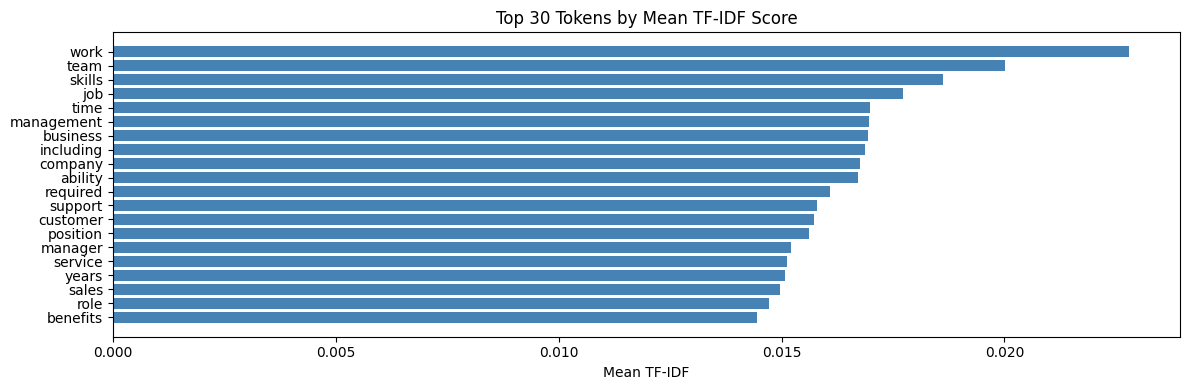

In [26]:
# --- Inspect top tokens ---
feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-20:][::-1]

plt.figure(figsize=(12, 4))
plt.barh([feature_names[i] for i in top_idx[::-1]],
         [mean_tfidf[i] for i in top_idx[::-1]],
         color='steelblue')
plt.title('Top 20 Tokens by Mean TF-IDF Score')
plt.xlabel('Mean TF-IDF')
plt.tight_layout()
plt.show()

## 6. Hybrid Recommendation Engine

Each job is scored against a query using a **weighted combination** of four similarity signals:

```
hybrid_score = 0.60 × text_sim
             + 0.15 × experience_sim
             + 0.15 × location_sim
             + 0.10 × salary_sim
```

| Signal | How computed |
|---|---|
| `text_sim` | Cosine similarity of TF-IDF vectors |
| `experience_sim` | `1 - │exp_query - exp_candidate│` (both normalised 0–1) |
| `location_sim` | `1.0` if same state, `0.0` otherwise |
| `salary_sim` | `1 - │salary_query - salary_candidate│` (both normalised 0–1) |

Weights are configurable via the `weights` parameter in each function.

In [27]:
# Default weights for hybrid scoring
DEFAULT_WEIGHTS = {
    'text':       0.60,
    'experience': 0.15,
    'location':   0.15,
    'salary':     0.10,
}

# Pre-extract structured arrays for fast vectorised operations
exp_array    = df['exp_norm'].values          # shape (N,)
salary_array = df['salary_norm'].values       # shape (N,)
state_array  = df['state'].values             # shape (N,)


def _hybrid_scores(text_sim: np.ndarray,
                   query_exp: float,
                   query_state: str,
                   query_salary: float,
                   weights: dict) -> np.ndarray:
    """
    Combine text cosine similarity with structured feature similarities.
    Returns a hybrid score array of shape (N,).
    """
    # Experience similarity: 1 - normalised absolute gap
    exp_sim    = 1.0 - np.abs(exp_array - query_exp)

    # Location similarity: binary state match
    loc_sim    = (state_array == query_state).astype(float)
    # If query state is unknown, location signal is neutral (0.5)
    if query_state == '':
        loc_sim[:] = 0.5

    # Salary similarity: 1 - normalised absolute gap
    sal_sim    = 1.0 - np.abs(salary_array - query_salary)

    return (weights['text']       * text_sim
          + weights['experience'] * exp_sim
          + weights['location']   * loc_sim
          + weights['salary']     * sal_sim)


def _format_results(indices: np.ndarray, scores: np.ndarray) -> pd.DataFrame:
    """Build a tidy results DataFrame from top indices and their scores."""
    results = df.iloc[indices][[
        'job_id', 'title', 'company_name', 'location',
        'formatted_experience_level', 'normalized_salary'
    ]].copy()
    results['hybrid_score'] = scores[indices].round(4)
    results = results.reset_index(drop=True)
    results.index += 1
    return results


# ── Query by job index ────────────────────────────────────────────────────────

def get_recommendations_by_index(job_idx: int,
                                  top_n: int = 10,
                                  weights: dict = DEFAULT_WEIGHTS) -> pd.DataFrame:
    """
    Recommend top_n jobs most similar to the job at job_idx,
    using the hybrid similarity score.
    """
    query_vec    = tfidf_matrix[job_idx]
    text_sim     = cosine_similarity(query_vec, tfidf_matrix).flatten()
    text_sim[job_idx] = 0   # exclude self

    query_exp    = exp_array[job_idx]
    query_state  = state_array[job_idx]
    query_salary = salary_array[job_idx]

    scores     = _hybrid_scores(text_sim, query_exp, query_state, query_salary, weights)
    top_idx    = scores.argsort()[-top_n:][::-1]
    return _format_results(top_idx, scores)


# ── Query by title keyword ────────────────────────────────────────────────────

def get_recommendations_by_title(title_query: str,
                                  top_n: int = 10,
                                  weights: dict = DEFAULT_WEIGHTS) -> pd.DataFrame:
    """
    Find the first job matching title_query, then return hybrid recommendations.
    """
    mask    = df['title'].str.contains(title_query, case=False, na=False)
    matches = df[mask]

    if matches.empty:
        print(f'No jobs found matching: "{title_query}"')
        return pd.DataFrame()

    job_idx   = matches.index[0]
    query_job = df.iloc[job_idx]

    print(f'Query job : "{query_job["title"]}" at {query_job["company_name"]}')
    print(f'Location  : {query_job["location"]}  |  State: {state_array[job_idx] or "unknown"}')
    print(f'Experience: {query_job["formatted_experience_level"]}  |  '
          f'Salary: ${query_job["normalized_salary"]:,.0f}' if pd.notna(query_job["normalized_salary"])
          else f'Experience: {query_job["formatted_experience_level"]}  |  Salary: N/A')
    print(f'Weights   : {weights}')
    print('-' * 70)

    return get_recommendations_by_index(job_idx, top_n, weights)


# ── Query by user profile (skills + structured preferences) ──────────────────

def get_recommendations_by_profile(skills: list,
                                    experience_level: str = None,
                                    location: str = None,
                                    salary_target: float = None,
                                    top_n: int = 10,
                                    weights: dict = DEFAULT_WEIGHTS) -> pd.DataFrame:
    """
    Recommend jobs for a job-seeker profile.

    Parameters
    ----------
    skills           : list of skill/keyword strings
    experience_level : one of 'Internship', 'Entry level', 'Associate',
                       'Mid-Senior level', 'Director', 'Executive'  (or None)
    location         : 2-letter state code e.g. 'CA', 'NY'  (or None)
    salary_target    : desired annual salary in USD  (or None)
    top_n            : number of recommendations
    weights          : dict with keys text/experience/location/salary
    """
    # --- Text similarity ---
    query_text = clean_text(' '.join(skills))
    query_vec  = tfidf.transform([query_text])
    text_sim   = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # --- Experience ---
    if experience_level and experience_level in EXP_ORDER:
        query_exp = EXP_ORDER[experience_level] / MAX_EXP
    else:
        query_exp = exp_median / MAX_EXP   # neutral

    # --- Location ---
    query_state = location.upper().strip() if location else ''

    # --- Salary ---
    if salary_target is not None:
        # Scale using same scaler fitted on the dataset
        query_salary = scaler.transform([[salary_target]])[0][0]
        query_salary = float(np.clip(query_salary, 0, 1))
    else:
        query_salary = float(df['salary_norm'].median())   # neutral

    scores  = _hybrid_scores(text_sim, query_exp, query_state, query_salary, weights)
    top_idx = scores.argsort()[-top_n:][::-1]

    print(f'Skills     : {skills}')
    print(f'Experience : {experience_level or "not specified"}')
    print(f'Location   : {location or "not specified"}')
    print(f'Salary     : ${salary_target:,.0f}' if salary_target else 'Salary     : not specified')
    print(f'Weights    : {weights}')
    print('-' * 70)

    return _format_results(top_idx, scores)


print('Hybrid recommendation functions defined.')

Hybrid recommendation functions defined.


## 7. Demo

### Demo A — Recommend by Job Title (hybrid scoring)

In [28]:
# Finds the first 'Data Scientist' job in the dataset and returns the
# top 10 most similar jobs using hybrid scoring (text + exp + location + salary)
recs = get_recommendations_by_title('Data Scientist', top_n=10)
display(recs)

Query job : "Data Scientist Job" at Armstrong World Industries
Location  : United States  |  State: unknown
Experience: Entry level  |  Salary: N/A
Weights   : {'text': 0.6, 'experience': 0.15, 'location': 0.15, 'salary': 0.1}
----------------------------------------------------------------------


,job_id,title,company_name,location,formatted_experience_level,normalized_salary,hybrid_score
1,3900981638,Project Engineer - OH Job,Armstrong World Industries,"Hilliard, OH",Entry level,91500.0,0.7043
2,3884434296,"Architectural Specialties Manager, North East Job",Armstrong World Industries,United States,Mid-Senior level,NaN,0.6412
3,3888938024,iO Data Scientist,Ochsner Health,"New Orleans, LA",Entry level,NaN,0.4717
4,3894211185,"Data Scientist, Marketplace Incentives",Scale AI,San Francisco Bay Area,Entry level,NaN,0.4569
5,3887713726,Junior Data Scientist - Python /Modeling,Expert Technical Solutions,"Atlanta, GA",Entry level,NaN,0.4534
6,3894206499,Data Scientist (Intermediate),USAA,"Colorado Springs, CO",Entry level,NaN,0.4520
7,3894207377,Data Scientist (Intermediate),USAA,"Tampa, FL",Entry level,NaN,0.4520
8,3894210138,Data Scientist (Intermediate),USAA,"San Antonio, TX",Entry level,NaN,0.4520
9,3894204625,Data Scientist (Intermediate),USAA,"Plano, TX",Entry level,125990.0,0.4520
10,3885858600,Residential Field Sales Representative,"WOW! Internet, Cable & Phone","Sanford, FL",Entry level,NaN,0.4464


In [29]:
# Same query but with text-only weights to compare — shows how structured
# features shift the ranking when experience/location/salary are included
print('=== Text-only weights ===')
text_only = {'text': 1.0, 'experience': 0.0, 'location': 0.0, 'salary': 0.0}
recs_text = get_recommendations_by_title('Software Engineer', top_n=10, weights=text_only)
display(recs_text)

print('\n=== Hybrid weights (default) ===')
recs_hybrid = get_recommendations_by_title('Software Engineer', top_n=10)
display(recs_hybrid)

=== Text-only weights ===
Query job : "Software Engineer" at nan
Location  : Los Angeles Metropolitan Area  |  State: unknown
Experience: nan  |  Salary: N/A
Weights   : {'text': 1.0, 'experience': 0.0, 'location': 0.0, 'salary': 0.0}
----------------------------------------------------------------------


,job_id,title,company_name,location,formatted_experience_level,normalized_salary,hybrid_score
1,3885846111,Software Engineer,Horizontal Talent,"Kansas City, MO",Entry level,NaN,0.5636
2,3901352218,Software Engineer,Apex Systems,Cincinnati Metropolitan Area,Mid-Senior level,NaN,0.4762
3,3900963293,Software Engineer,Soni,New York City Metropolitan Area,Mid-Senior level,NaN,0.4467
4,3894993392,Software Engineer in Test,VRN Technologies,"Phoenix, AZ",NaN,NaN,0.4158
5,3889769846,Software Engineer,Goldman Sachs,"Dallas, TX",Mid-Senior level,141440.0,0.4145
6,3885114238,Software Engineer,NaN,United States,NaN,NaN,0.4104
7,3894540846,Software Engineer,Open Systems Technologies,"Chicago, IL",Entry level,200000.0,0.4060
8,3886204594,Software Engineer,Mercor,United States,NaN,NaN,0.3876
9,3889498613,Software Engineer,Arrow Search Partners,"New York, NY",Entry level,NaN,0.3799
10,3887100103,Embedded Software Engineer,ApTask,"Spring, TX",NaN,NaN,0.3755



=== Hybrid weights (default) ===
Query job : "Software Engineer" at nan
Location  : Los Angeles Metropolitan Area  |  State: unknown
Experience: nan  |  Salary: N/A
Weights   : {'text': 0.6, 'experience': 0.15, 'location': 0.15, 'salary': 0.1}
----------------------------------------------------------------------


,job_id,title,company_name,location,formatted_experience_level,normalized_salary,hybrid_score
1,3901352218,Software Engineer,Apex Systems,Cincinnati Metropolitan Area,Mid-Senior level,NaN,0.6107
2,3885846111,Software Engineer,Horizontal Talent,"Kansas City, MO",Entry level,NaN,0.6031
3,3900963293,Software Engineer,Soni,New York City Metropolitan Area,Mid-Senior level,NaN,0.5930
4,3894993392,Software Engineer in Test,VRN Technologies,"Phoenix, AZ",NaN,NaN,0.5745
5,3889769846,Software Engineer,Goldman Sachs,"Dallas, TX",Mid-Senior level,141440.0,0.5737
6,3885114238,Software Engineer,NaN,United States,NaN,NaN,0.5712
7,3886204594,Software Engineer,Mercor,United States,NaN,NaN,0.5575
8,3887100103,Embedded Software Engineer,ApTask,"Spring, TX",NaN,NaN,0.5503
9,3884839409,Senior Software Engineer,Boomi,"Conshohocken, PA",NaN,NaN,0.5462
10,3884811061,Software Engineer,LemaTech LLC,United States,NaN,NaN,0.5419


### Demo B — Recommend by Full User Profile

The `get_recommendations_by_profile` function accepts a complete job-seeker profile including **skills**, **experience level**, **preferred state**, and **target salary**.

In [30]:
# Profile 1: Mid-level Data/ML engineer in California, ~$120K
recs_profile1 = get_recommendations_by_profile(
    skills           = ['python', 'machine learning', 'deep learning', 'tensorflow', 'sql'],
    experience_level = 'Mid-Senior level',
    location         = 'CA',
    salary_target    = 120_000,
    top_n            = 10
)
display(recs_profile1)

Skills     : ['python', 'machine learning', 'deep learning', 'tensorflow', 'sql']
Experience : Mid-Senior level
Location   : CA
Salary     : $120,000
Weights    : {'text': 0.6, 'experience': 0.15, 'location': 0.15, 'salary': 0.1}
----------------------------------------------------------------------


,job_id,title,company_name,location,formatted_experience_level,normalized_salary,hybrid_score
1,3898175710,Machine Learning Performance Architect,d-Matrix,"Santa Clara, CA",NaN,NaN,0.5989
2,3890861573,Senior Machine Learning Engineer,NaN,"San Francisco, CA",NaN,NaN,0.5909
3,3888959259,Software Engineer V,BCforward,"Menlo Park, CA",Mid-Senior level,NaN,0.5564
4,3898159293,Machine Learning Operations and Data Engineer,Emancro,"Berkeley, CA",NaN,165000.0,0.5553
5,3901166848,Computer Vision/ Machine Learning Engineer,Akkodis,"Los Angeles, CA",Mid-Senior level,145600.0,0.5496
6,3895804790,Senior Developer Relationship Manager – Physic...,NVIDIA,"Santa Clara, CA",Mid-Senior level,259625.0,0.5397
7,3886488846,Senior Machine Learning Engineer,Samson Rose,"Los Angeles, CA",Mid-Senior level,NaN,0.5378
8,3894871488,"Senior Software Engineer, Machine Learning",ZipRecruiter,"Palo Alto, CA",NaN,NaN,0.5335
9,3894873232,"Senior Software Engineer, Machine Learning",ZipRecruiter,"Santa Monica, CA",NaN,NaN,0.5335
10,3885845727,AI/ML Engineer (Contract) (Hybrid) – 4313,HIRECLOUT,"Irvine, CA",NaN,166400.0,0.5321


In [31]:
# Profile 2: Entry-level marketing graduate in New York, ~$50K
recs_profile2 = get_recommendations_by_profile(
    skills           = ['marketing', 'social media', 'content creation', 'google analytics', 'seo'],
    experience_level = 'Entry level',
    location         = 'NY',
    salary_target    = 50_000,
    top_n            = 10
)
display(recs_profile2)

Skills     : ['marketing', 'social media', 'content creation', 'google analytics', 'seo']
Experience : Entry level
Location   : NY
Salary     : $50,000
Weights    : {'text': 0.6, 'experience': 0.15, 'location': 0.15, 'salary': 0.1}
----------------------------------------------------------------------


,job_id,title,company_name,location,formatted_experience_level,normalized_salary,hybrid_score
1,3895239016,PR & Social Media Intern,Bao Communications,"New York, NY",NaN,NaN,0.5698
2,3888957100,Marketing Content Specialist,The Lenard Team,"Smithtown, NY",Entry level,38000.0,0.5661
3,3891270138,Social Media & Digital Content Creator,Post House,"Sag Harbor, NY",NaN,NaN,0.5337
4,3895501969,Social Media Marketing Intern,NaN,"Smithtown, NY",NaN,NaN,0.5166
5,3894950886,"Account Coordinator, Social Media",MMGY Global,"New York, NY",Entry level,NaN,0.5080
6,3900980694,Paid Social Manager,NaN,"Brooklyn, NY",NaN,102500.0,0.5069
7,3887489289,Marketing Intern,SilkCut Underwear,"Brooklyn, NY",NaN,31200.0,0.5045
8,3891036360,Social Media Marketing Intern,SUM,"New York, NY",NaN,NaN,0.5000
9,3885102527,Social Media Writer,NaN,"Manhattan, NY",NaN,NaN,0.4997
10,3898159983,"Supervisor, Social Planning/Buying",Publicis Media,"New York, NY",Mid-Senior level,80000.0,0.4933


### Demo C — Weight Sensitivity Analysis

Shows how changing the weight of each structured signal affects which jobs surface.

In [32]:
# Compare top-5 titles returned under three different weight configurations
# for a fixed profile: Python engineer, Mid-Senior, TX, $100K

profile_kwargs = dict(
    skills           = ['python', 'sql', 'data engineering', 'spark', 'aws'],
    experience_level = 'Mid-Senior level',
    location         = 'TX',
    salary_target    = 100_000,
    top_n            = 5
)

weight_configs = {
    'Text only'     : {'text': 1.00, 'experience': 0.00, 'location': 0.00, 'salary': 0.00},
    'Default hybrid': {'text': 0.60, 'experience': 0.15, 'location': 0.15, 'salary': 0.10},
    'Location heavy': {'text': 0.50, 'experience': 0.10, 'location': 0.35, 'salary': 0.05},
    'Salary heavy'  : {'text': 0.50, 'experience': 0.10, 'location': 0.05, 'salary': 0.35},
}

for config_name, w in weight_configs.items():
    print(f'\n{"=" * 60}')
    print(f'  Config: {config_name}')
    print(f'  Weights: {w}')
    print(f'{"=" * 60}')
    r = get_recommendations_by_profile(**profile_kwargs, weights=w)
    display(r[['title', 'location', 'formatted_experience_level', 'normalized_salary', 'hybrid_score']])


  Config: Text only
  Weights: {'text': 1.0, 'experience': 0.0, 'location': 0.0, 'salary': 0.0}
Skills     : ['python', 'sql', 'data engineering', 'spark', 'aws']
Experience : Mid-Senior level
Location   : TX
Salary     : $100,000
Weights    : {'text': 1.0, 'experience': 0.0, 'location': 0.0, 'salary': 0.0}
----------------------------------------------------------------------


,title,location,formatted_experience_level,normalized_salary,hybrid_score
1,Software Specialist,"Richmond, VA",NaN,NaN,0.3622
2,Data Engineer,"Los Angeles, CA",NaN,NaN,0.3306
3,Data Engineering Analyst,"Denver, CO",Entry level,NaN,0.3214
4,"Sr Data engineer with AWS, PYTHON (W2)",United States,NaN,NaN,0.3164
5,Data Engineer,"McLean, VA",Entry level,140000.0,0.3160



  Config: Default hybrid
  Weights: {'text': 0.6, 'experience': 0.15, 'location': 0.15, 'salary': 0.1}
Skills     : ['python', 'sql', 'data engineering', 'spark', 'aws']
Experience : Mid-Senior level
Location   : TX
Salary     : $100,000
Weights    : {'text': 0.6, 'experience': 0.15, 'location': 0.15, 'salary': 0.1}
----------------------------------------------------------------------


,title,location,formatted_experience_level,normalized_salary,hybrid_score
1,Data Engineer,"Houston, TX",Mid-Senior level,NaN,0.5772
2,Data Engineer,"Dallas, TX",NaN,NaN,0.5364
3,Data Engineer 3: 24-00989,"Austin, TX",Mid-Senior level,112320.0,0.5362
4,Data Engineering Architect- AWS Cloud,"Dallas, TX",Mid-Senior level,NaN,0.5360
5,Azure Data Engineer,"Plano, TX",NaN,NaN,0.5304



  Config: Location heavy
  Weights: {'text': 0.5, 'experience': 0.1, 'location': 0.35, 'salary': 0.05}
Skills     : ['python', 'sql', 'data engineering', 'spark', 'aws']
Experience : Mid-Senior level
Location   : TX
Salary     : $100,000
Weights    : {'text': 0.5, 'experience': 0.1, 'location': 0.35, 'salary': 0.05}
----------------------------------------------------------------------


,title,location,formatted_experience_level,normalized_salary,hybrid_score
1,Data Engineer,"Houston, TX",Mid-Senior level,NaN,0.6477
2,Data Engineer,"Dallas, TX",NaN,NaN,0.6137
3,Data Engineer 3: 24-00989,"Austin, TX",Mid-Senior level,112320.0,0.6135
4,Data Engineering Architect- AWS Cloud,"Dallas, TX",Mid-Senior level,NaN,0.6133
5,Azure Data Engineer,"Plano, TX",NaN,NaN,0.6087



  Config: Salary heavy
  Weights: {'text': 0.5, 'experience': 0.1, 'location': 0.05, 'salary': 0.35}
Skills     : ['python', 'sql', 'data engineering', 'spark', 'aws']
Experience : Mid-Senior level
Location   : TX
Salary     : $100,000
Weights    : {'text': 0.5, 'experience': 0.1, 'location': 0.05, 'salary': 0.35}
----------------------------------------------------------------------


,title,location,formatted_experience_level,normalized_salary,hybrid_score
1,Data Engineer,"Houston, TX",Mid-Senior level,NaN,0.6477
2,Software Specialist,"Richmond, VA",NaN,NaN,0.6311
3,Data Engineer,"Los Angeles, CA",NaN,NaN,0.6153
4,Data Engineer,"Dallas, TX",NaN,NaN,0.6137
5,Data Engineer 3: 24-00989,"Austin, TX",Mid-Senior level,112320.0,0.6135


### Demo C — Similarity Heatmap

Visualise pairwise cosine similarity for a small set of diverse jobs.

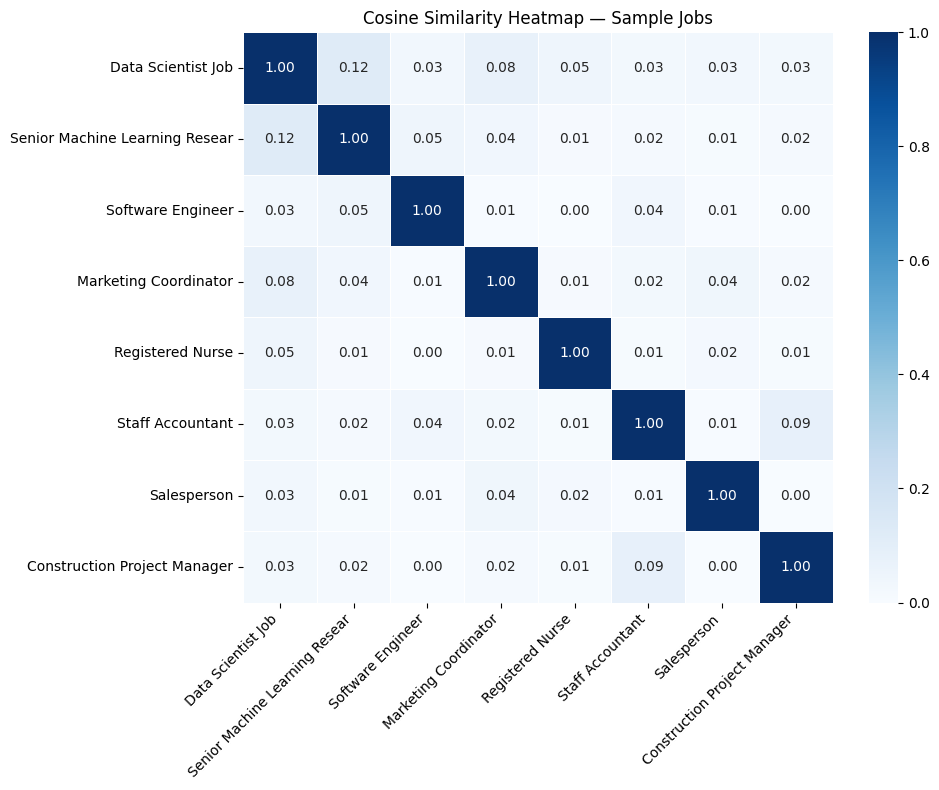

In [33]:
# Sample one job from each of 8 different title categories
sample_titles = [
    'Data Scientist', 'Machine Learning', 'Software Engineer',
    'Marketing', 'Nurse', 'Accountant', 'Sales', 'Project Manager'
]

sample_indices = []
sample_labels  = []

for t in sample_titles:
    mask = df['title'].str.contains(t, case=False, na=False)
    if mask.any():
        idx = df[mask].index[0]
        sample_indices.append(idx)
        sample_labels.append(df.iloc[idx]['title'][:30])

sample_matrix = tfidf_matrix[sample_indices]
sim_matrix    = cosine_similarity(sample_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    xticklabels=sample_labels,
    yticklabels=sample_labels,
    annot=True, fmt='.2f',
    cmap='Blues', vmin=0, vmax=1,
    linewidths=0.5
)
plt.title('Cosine Similarity Heatmap — Sample Jobs')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Evaluation

Since we have no explicit user-job interaction labels, we use **surrogate evaluation**:

- **Title Match Rate** — what % of top-N recommendations share a similar title category as the query?
- **Intra-list Diversity** — average pairwise dissimilarity among recommendations (avoids filter bubbles)
- **Coverage** — what % of the catalogue can be recommended?

In [34]:
def title_match_rate(job_idx: int, top_n: int = 10) -> float:
    """
    Proxy precision: fraction of top-N recs whose title contains
    at least one keyword from the query job's title.
    """
    query_title = df.iloc[job_idx]['title'].lower()
    keywords    = set(re.findall(r'\b\w{4,}\b', query_title))  # words >= 4 chars

    if not keywords:
        return 0.0

    recs = get_recommendations_by_index(job_idx, top_n)
    matched = 0
    for rec_title in recs['title'].str.lower():
        if any(kw in rec_title for kw in keywords):
            matched += 1
    return matched / top_n


def intra_list_diversity(job_idx: int, top_n: int = 10) -> float:
    """
    Average pairwise cosine DISTANCE among recommendations.
    Higher = more diverse recommendations.
    """
    query_vec   = tfidf_matrix[job_idx]
    sim_scores  = cosine_similarity(query_vec, tfidf_matrix).flatten()
    sim_scores[job_idx] = 0
    top_indices = sim_scores.argsort()[-top_n:][::-1]
    rec_matrix  = tfidf_matrix[top_indices]
    pairwise    = cosine_similarity(rec_matrix)
    n = len(top_indices)
    # Average off-diagonal (pairwise distances)
    dist = 1 - pairwise
    avg_dist = (dist.sum() - np.trace(dist)) / (n * (n - 1))
    return avg_dist


print('Evaluation functions defined.')

Evaluation functions defined.


In [35]:
# --- Run evaluation on a sample of 200 random jobs ---
np.random.seed(42)
eval_sample = np.random.choice(len(df), size=200, replace=False)

tmr_scores  = []
ild_scores  = []

for idx in eval_sample:
    tmr_scores.append(title_match_rate(idx, top_n=10))
    ild_scores.append(intra_list_diversity(idx, top_n=10))

print('=== Evaluation Results (200 random queries, Top-10) ===')
print(f'Title Match Rate  (Proxy Precision@10): {np.mean(tmr_scores):.3f}  ± {np.std(tmr_scores):.3f}')
print(f'Intra-list Diversity                  : {np.mean(ild_scores):.3f}  ± {np.std(ild_scores):.3f}')
print(f'Catalogue Coverage                    : {len(df):,} / {len(df):,} = 100% (all items can be queried)')

=== Evaluation Results (200 random queries, Top-10) ===
Title Match Rate  (Proxy Precision@10): 0.585  ± 0.324
Intra-list Diversity                  : 0.550  ± 0.270
Catalogue Coverage                    : 50,000 / 50,000 = 100% (all items can be queried)


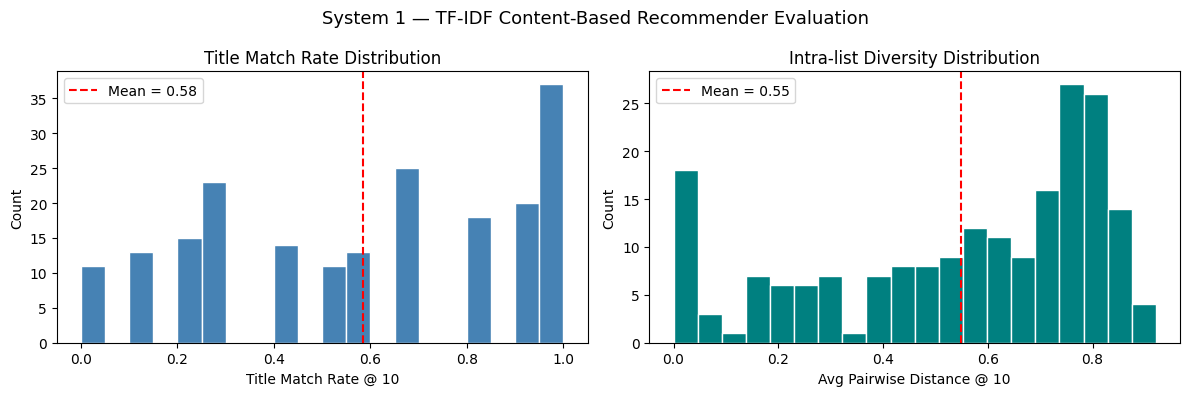

In [36]:
# --- Visualise evaluation distributions ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(tmr_scores, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(tmr_scores), color='red', linestyle='--', label=f'Mean = {np.mean(tmr_scores):.2f}')
axes[0].set_title('Title Match Rate Distribution')
axes[0].set_xlabel('Title Match Rate @ 10')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(ild_scores, bins=20, color='teal', edgecolor='white')
axes[1].axvline(np.mean(ild_scores), color='red', linestyle='--', label=f'Mean = {np.mean(ild_scores):.2f}')
axes[1].set_title('Intra-list Diversity Distribution')
axes[1].set_xlabel('Avg Pairwise Distance @ 10')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('System 1 — TF-IDF Content-Based Recommender Evaluation', fontsize=13)
plt.tight_layout()
plt.show()

## Summary

| Component | Detail |
|---|---|
| **Dataset** | LinkedIn Job Postings — 50,000 sampled rows |
| **Text features** | `title` (×3)  + `description` (×1) |
| **Structured features** | Experience (ordinal 0–1), State (binary match), Salary (min-max 0–1) |
| **Vectoriser** | TF-IDF — 15K features, 1–2 ngrams, English stopwords |
| **Scoring** | Weighted hybrid: 60% text + 15% experience + 15% location + 10% salary |
| **Query modes** | By index · By title keyword · By full user profile |
| **Weights** | Configurable per query via `weights=` parameter |
| **Evaluation** | Title Match Rate (proxy precision) · Intra-list Diversity |

### Limitations
- TF-IDF is a **bag-of-words** model — ignores word order and semantics
- Location signal is **state-level only** — city proximity not captured
- Salary similarity assumes **linear preference** around a target — in practice candidates often accept a range
- These limitations motivate **System 2** (embedding-based / collaborative approach)

## 9. System 2 — Embedding-Based Recommender (Word2Vec)

**Why a second system?**
TF-IDF treats every word as an independent feature — it has no understanding of meaning. *"Software engineer"* and *"developer"* score zero similarity despite being nearly synonymous.

**Word2Vec** learns dense vector representations where semantically similar words end up close together in vector space. Each job is represented by averaging its word vectors, capturing *meaning* rather than just keyword overlap.

| | System 1 (TF-IDF) | System 2 (Word2Vec) |
|---|---|---|
| Similarity type | Keyword overlap | Semantic meaning |
| Handles synonyms | No | Yes |
| Training required | No | Yes (on this corpus) |
| Interpretable | High | Lower |
| Speed | Fast | Moderate |

The two systems are genuinely **complementary**: System 1 is precise on exact job terminology; System 2 generalises across related roles and synonymous skills.

In [37]:
!pip install gensim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.4 MB/s eta 0:00:00


In [38]:
from gensim.models import Word2Vec

# Tokenise the pre-cleaned content field (reuse work from Section 4)
print('Tokenising job content...')
tokenised_content = [text.split() for text in df['content']]

# Train Word2Vec on the job corpus
print(f'Training Word2Vec on {len(tokenised_content):,} job postings...')
w2v_model = Word2Vec(
    sentences   = tokenised_content,
    vector_size = 100,    # 100-dimensional embeddings
    window      = 5,      # words within ±5 positions are considered context
    min_count   = 2,      # ignore tokens appearing fewer than 2 times
    workers     = 4,
    epochs      = 5,
    seed        = 42
)
print(f'Vocabulary size: {len(w2v_model.wv):,} unique tokens')

Tokenising job content...
Training Word2Vec on 50,000 job postings...
Vocabulary size: 88,133 unique tokens


In [39]:
# Build one vector per job by averaging the Word2Vec vectors of its tokens.
# Jobs whose tokens are all out-of-vocabulary get a zero vector.

def get_job_vector(tokens: list, model) -> np.ndarray:
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)


print('Building job vectors (averaging word embeddings)...')
job_vectors = np.vstack([get_job_vector(t, w2v_model) for t in tokenised_content])
print(f'Job vector matrix: {job_vectors.shape}  ({job_vectors.shape[0]:,} jobs × {job_vectors.shape[1]} dims)')

Building job vectors (averaging word embeddings)...
Job vector matrix: (50000, 100)  (50,000 jobs × 100 dims)


In [40]:
def get_sys2_recommendations(job_idx: int, top_n: int = 10) -> pd.DataFrame:
    """Return top_n jobs most similar to job_idx using Word2Vec embeddings."""
    query_vec = job_vectors[job_idx].reshape(1, -1)
    sims      = cosine_similarity(query_vec, job_vectors).flatten()
    sims[job_idx] = 0   # exclude self
    top_idx   = sims.argsort()[-top_n:][::-1]

    results = df.iloc[top_idx][[
        'job_id', 'title', 'company_name', 'location',
        'formatted_experience_level', 'normalized_salary'
    ]].copy()
    results['similarity'] = sims[top_idx].round(4)
    results = results.reset_index(drop=True)
    results.index += 1
    return results


print('System 2 recommendation function defined.')

System 2 recommendation function defined.


In [41]:
# --- Demo: System 2 recommendations ---
print('=== System 2 Demo: Recommendations for "Data Scientist" ===\n')

mask = df['title'].str.contains('Data Scientist', case=False, na=False)
if mask.any():
    idx = df[mask].index[0]
    print(f'Query job : "{df.iloc[idx]["title"]}" at {df.iloc[idx]["company_name"]}')
    print(f'Location  : {df.iloc[idx]["location"]}')
    print('-' * 60)
    display(get_sys2_recommendations(idx, top_n=10))

=== System 2 Demo: Recommendations for "Data Scientist" ===

Query job : "Data Scientist Job" at Armstrong World Industries
Location  : United States
------------------------------------------------------------


,job_id,title,company_name,location,formatted_experience_level,normalized_salary,similarity
1,3884435469,Dashboard BI Developer,Gainwell Technologies,"Pennsylvania, United States",Mid-Senior level,67500.0,0.9771
2,3900981638,Project Engineer - OH Job,Armstrong World Industries,"Hilliard, OH",Entry level,91500.0,0.9660
3,3900957963,Data Analyst,IBM,"Washington, DC",NaN,109103.5,0.9640
4,3900959657,Failure Analysis Engineer,IBM,"Albany, NY",NaN,138000.0,0.9618
5,3900960379,Technical Lead,IBM,"Herndon, VA",NaN,141396.0,0.9614
6,3900961347,QA Test Developer,IBM,"Herndon, VA",NaN,137603.5,0.9609
7,3886845515,Principal Application Engineer - Full Stack,Discover Financial Services,"Riverwoods, IL",Mid-Senior level,118900.0,0.9609
8,3900960352,UI/UX Designer,IBM,"Washington, DC",NaN,137603.5,0.9605
9,3900955097,"Senior Software Frontend Engineer, Moderation ...",Roblox,"San Mateo, CA",Mid-Senior level,251160.0,0.9590
10,3889103440,"Staff Data Scientist, SSP.",InMobi,"San Mateo, CA",NaN,204765.5,0.9590


## 10. Evaluation — NDCG & MAP

Two standard ranking metrics used across both systems:

**NDCG@K (Normalised Discounted Cumulative Gain)**
Rewards placing relevant items *high* in the ranked list — position 1 contributes much more than position 10. Normalised against the ideal ranking so scores are always between 0 and 1.

**MAP@K (Mean Average Precision)**
Computes precision at each position where a relevant item appears, then averages. Rewards both finding relevant items *and* finding them early.

Since we have no explicit user ratings, relevance is approximated using a **surrogate label**: a recommended job is considered relevant if its title shares a keyword (≥ 4 characters) with the query job title — the same proxy used in Section 8.

In [42]:
def dcg_at_k(relevances: list, k: int) -> float:
    """Discounted Cumulative Gain at K — higher ranks contribute more."""
    return sum(rel / np.log2(i + 2) for i, rel in enumerate(relevances[:k]))


def ndcg_at_k(relevances: list, k: int) -> float:
    """
    Normalised DCG at K.
    Divides actual DCG by the ideal DCG (best possible ranking).
    Returns 0 if there are no relevant items.
    """
    ideal_dcg = dcg_at_k(sorted(relevances, reverse=True), k)
    if ideal_dcg == 0:
        return 0.0
    return dcg_at_k(relevances, k) / ideal_dcg


def average_precision(relevances: list) -> float:
    """
    Average Precision — precision computed at each relevant item position,
    then averaged. Rewards placing relevant items early in the list.
    """
    hits, total = 0, 0.0
    for i, rel in enumerate(relevances):
        if rel:
            hits += 1
            total += hits / (i + 1)
    return total / max(hits, 1)


print('NDCG and MAP metric functions defined.')

NDCG and MAP metric functions defined.


In [43]:
# --- Run NDCG & MAP on both systems (200 random queries) ---
np.random.seed(42)
eval_indices = np.random.choice(len(df), size=200, replace=False)

sys1_ndcg, sys1_map = [], []
sys2_ndcg, sys2_map = [], []
TOP_K = 10

for idx in eval_indices:
    query_title = df.iloc[idx]['title'].lower()
    keywords    = set(re.findall(r'\b\w{4,}\b', query_title))

    if not keywords:
        continue

    # System 1 recs
    s1_recs   = get_recommendations_by_index(idx, top_n=TOP_K)
    s1_rel    = [int(any(kw in t for kw in keywords))
                 for t in s1_recs['title'].str.lower()]

    # System 2 recs
    s2_recs   = get_sys2_recommendations(idx, top_n=TOP_K)
    s2_rel    = [int(any(kw in t for kw in keywords))
                 for t in s2_recs['title'].str.lower()]

    sys1_ndcg.append(ndcg_at_k(s1_rel, TOP_K))
    sys1_map.append(average_precision(s1_rel))
    sys2_ndcg.append(ndcg_at_k(s2_rel, TOP_K))
    sys2_map.append(average_precision(s2_rel))

print('=== NDCG & MAP Evaluation (200 queries, Top-10) ===\n')
print(f'{"Metric":<22} {"System 1 (TF-IDF)":>20} {"System 2 (Word2Vec)":>22}')
print('-' * 66)
print(f'{"NDCG@10":<22} {np.mean(sys1_ndcg):>20.4f} {np.mean(sys2_ndcg):>22.4f}')
print(f'{"MAP@10":<22} {np.mean(sys1_map):>20.4f} {np.mean(sys2_map):>22.4f}')

=== NDCG & MAP Evaluation (200 queries, Top-10) ===

Metric                    System 1 (TF-IDF)    System 2 (Word2Vec)
------------------------------------------------------------------
NDCG@10                              0.8323                 0.7859
MAP@10                               0.7602                 0.7050


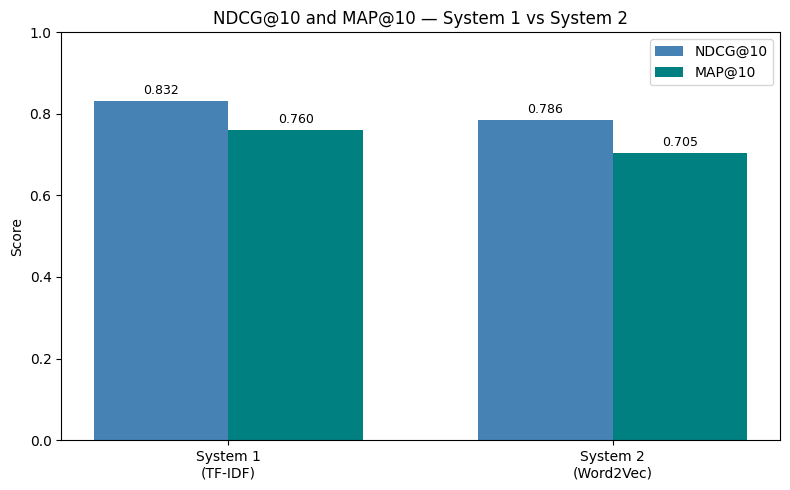

In [44]:
# --- Visualise NDCG & MAP comparison ---
systems   = ['System 1\n(TF-IDF)', 'System 2\n(Word2Vec)']
ndcg_vals = [np.mean(sys1_ndcg), np.mean(sys2_ndcg)]
map_vals  = [np.mean(sys1_map),  np.mean(sys2_map)]

x     = np.arange(len(systems))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width / 2, ndcg_vals, width, label='NDCG@10', color='steelblue')
bars2 = ax.bar(x + width / 2, map_vals,  width, label='MAP@10',  color='teal')

ax.set_ylabel('Score')
ax.set_title('NDCG@10 and MAP@10 — System 1 vs System 2')
ax.set_xticks(x)
ax.set_xticklabels(systems)
ax.set_ylim(0, 1)
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 11. Cold-Start Mitigation

The **cold-start problem** arises when the system has insufficient information about a new user or item:

- **New user cold-start:** The user has no interaction history, so there's nothing to base personalised recommendations on.
- **New item cold-start:** A job posting just added has zero views or applies, so engagement-based signals are unavailable.

### Strategies Used

| Scenario | Strategy | How |
|---|---|---|
| **New user** | **Profile-based onboarding** | Ask for skills, experience level, location, and salary target upfront — feed directly into `get_recommendations_by_profile` |
| **New item** | **Popularity-based fallback** | Recommend globally popular jobs (high views + applies) filtered by experience and state. Once the new job gains engagement, it enters normal ranking. |

Content-based filtering is naturally **more resilient to new items** than collaborative filtering — as long as the job has a title or description, it can be compared to other jobs immediately.

In [45]:
# --- Popularity-based fallback for new/unseen items ---
# When a job posting is brand new (no views/applies yet), we can't rank it by engagement.
# Solution: fall back to globally popular jobs that match the user's basic filters.

df['popularity_score'] = (
    df['views'].fillna(0)   * 0.4 +
    df['applies'].fillna(0) * 0.6
)
df['popularity_score'] = MinMaxScaler().fit_transform(df[['popularity_score']])


def get_popular_jobs(experience_level: str = None,
                     location: str = None,
                     top_n: int = 10) -> pd.DataFrame:
    """
    Cold-start fallback: return top-N most-viewed/applied jobs,
    optionally filtered by experience level and/or state.
    If the filtered set is too small, falls back to the global top-N.
    """
    mask = pd.Series([True] * len(df), index=df.index)

    if experience_level:
        mask &= df['formatted_experience_level'] == experience_level
    if location:
        mask &= df['state'] == location.upper()

    subset = df[mask] if mask.sum() >= top_n else df   # global fallback

    top = (subset
           .nlargest(top_n, 'popularity_score')
           [['job_id', 'title', 'company_name', 'location',
             'formatted_experience_level', 'normalized_salary', 'popularity_score']]
           .reset_index(drop=True))
    top.index += 1
    return top


print('=== Cold-Start: New Item (no engagement data yet) ===')
print('Strategy: recommend popular jobs matching experience level + location\n')
print('Top 5 popular Entry-level jobs in NY:')
display(get_popular_jobs(experience_level='Entry level', location='NY', top_n=5))

=== Cold-Start: New Item (no engagement data yet) ===
Strategy: recommend popular jobs matching experience level + location

Top 5 popular Entry-level jobs in NY:


,job_id,title,company_name,location,formatted_experience_level,normalized_salary,popularity_score
1,3887877451,Executive Administrative Assistant,NBCUniversal,"New York, NY",Entry level,65000.0,1.000000
2,3898165862,"Data Analyst, Medicare Sales & Retention",Healthfirst,"New York, NY",Entry level,NaN,0.042546
3,3901349998,Human Resources Coordinator,JOE & THE JUICE,"New York, NY",Entry level,49920.0,0.031771
4,3900090742,Social Media Content Creator,International Rescue Committee,"New York, NY",Entry level,NaN,0.022050
5,3889702368,Human Resource Coordinator,Arrow Search Partners,"New York, NY",Entry level,75000.0,0.020697


In [46]:
# --- Demo: cold-start for a brand-new user with no history ---
print('=== Cold-Start: New User (no history) ===')
print('Strategy: collect basic preferences via profile, then use profile-based recommender\n')

new_user = dict(
    skills           = ['javascript', 'react', 'node.js', 'typescript'],
    experience_level = 'Entry level',
    location         = 'TX',
    salary_target    = 70_000,
    top_n            = 5
)

recs_new_user = get_recommendations_by_profile(**new_user)
display(recs_new_user)

=== Cold-Start: New User (no history) ===
Strategy: collect basic preferences via profile, then use profile-based recommender

Skills     : ['javascript', 'react', 'node.js', 'typescript']
Experience : Entry level
Location   : TX
Salary     : $70,000
Weights    : {'text': 0.6, 'experience': 0.15, 'location': 0.15, 'salary': 0.1}
----------------------------------------------------------------------


,job_id,title,company_name,location,formatted_experience_level,normalized_salary,hybrid_score
1,3895214400,Full Stack Developer (Sr. NodeJS),Compunnel Inc.,"Irving, TX",Mid-Senior level,NaN,0.5873
2,3894938445,Lead React Developer (15 Years Only),TekValue IT Solutions,"Dallas, TX",NaN,150800.0,0.5869
3,3890889843,Technical Architect,Photon,"Dallas, TX",Mid-Senior level,NaN,0.5798
4,3886882867,Backend Node JS Developer (Only W2),TechWish,"Dallas, TX",Mid-Senior level,NaN,0.5565
5,3899542278,Node.js Developer with AWS,Nityo Infotech,"Plano, TX",NaN,NaN,0.5339


## 12. Generative AI in Recommender Systems

Generative AI models can enhance recommender systems in ways traditional methods cannot — by *learning* to generate plausible user-item interactions rather than just measuring similarity.

### Key Models

**Variational Autoencoders (VAEs)**
- Encode user preferences into a compressed latent space, then decode to reconstruct interaction signals
- **Mult-VAE** (Liang et al., 2018) applies multinomial likelihood for implicit feedback (clicks, applies) — outperforms matrix factorisation on sparse data
- Advantage: naturally handles uncertainty and generates diverse, personalised recommendations

**Generative Adversarial Networks (GANs)**
- Generator proposes candidate items; discriminator scores their relevance — both improve through competition
- **CFGAN** trains a GAN on user-item interaction matrices to synthesise realistic preference patterns
- **RecGAN** uses the generator to augment sparse interaction data, directly reducing cold-start impact

---

### Comparison vs. Our Implemented Systems

| Aspect | System 1 (TF-IDF) | System 2 (Word2Vec) | Generative AI (VAE / GAN) |
|---|---|---|---|
| Learns from interactions | No | No | Yes |
| Semantic understanding | Low (keyword) | Medium (context) | High (latent space) |
| Cold-start handling | Profile fallback | Profile fallback | Data augmentation via GAN |
| Scalability | High | Medium | Low–Medium (training cost) |
| Explainability | High | Medium | Low (black box) |
| Data requirement | Text only | Text only | Interaction history needed |

---

### How Generative AI Could Improve This System

1. **Mult-VAE** could replace TF-IDF by learning dense job embeddings from apply/view behaviour — capturing *why* users engage, not just *what* keywords match
2. **CFGAN** could synthesise missing user–job interaction data, directly addressing cold-start for newly posted jobs with zero views
3. A **conditional VAE** conditioned on user profile (skills, experience, salary target) could generate a personalised job feature distribution, making profile-based queries far more expressive than our current weighted average

### Limitations of Generative Approaches
- Require large interaction datasets — our dataset has per-job view/apply counts but **no per-user interaction history**, making GAN/VAE training impractical here
- GANs suffer from training instability; VAEs can suffer from posterior collapse
- Much lower interpretability than keyword-based or embedding-based systems — harder to justify recommendations to users